# Modeling Master — Punjab Stubble-Burning Fire Prediction

End-to-end pipeline on the **clean** master feature table
(`punjab_features_master_clean.csv`, 56,160 rows × 78 cols).

| Phase | Content | Execute |
|-------|---------|---------|
| 0 | Setup, imports, colour palette | ✓ Auto |
| 1 | Load data, define feature groups + temporal splits | ✓ Auto |
| 2 | Evaluation helpers + persistence baseline | ✓ Auto |
| 3 | Ablation ladder — FIRMS → +NDVI → +Weather → +Policy | ✗ Colab |
| 4 | Optuna hyperparameter tuning (100 trials) | ✗ Colab |
| 5 | SHAP — top-20 features + family share + beeswarm | ✗ Colab |
| 6 | Calibration plot + threshold sensitivity sweep | ✗ Colab |
| 7 | Stratified MAE + per-district + lead-time (t+1/t+2/t+4) | ✗ Colab |
| 8 | Predicted vs observed Punjab heatmap | ✗ Colab |
| 9 | ConvLSTM stretch model (PyTorch) | ✗ Colab |
| 10 | Final summary table | ✗ Colab |

> **Phases 3–10 contain cells that are authored but NOT pre-executed.**
> Run them in Colab (GPU recommended for Phase 9).


## Phase 0 — Setup

In [1]:
import os, sys, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ORANGE = '#E8512A'
GREEN  = '#27AE60'
NAVY   = '#1F3A93'
GREY   = '#7F8C8D'
PURPLE = '#9B59B6'

plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['figure.dpi']        = 120

os.makedirs('models',  exist_ok=True)
os.makedirs('figures', exist_ok=True)
os.makedirs('outputs', exist_ok=True)

print('Setup OK')


Setup OK


## Phase 1 — Load Data & Define Feature Groups

In [2]:
df = pd.read_csv('punjab_features_master_clean.csv')
print(f'Master clean: {df.shape}')
print(f'Columns: {list(df.columns)}')


Master clean: (3312, 78)
Columns: ['grid_id', 'grid_x', 'grid_y', 'year', 'week', 'week_of_season', 'fire_count_raw', 'fire_count_weighted', 'fire_count_filtered', 'fire_count_last_week', 'same_week_last_year', '3yr_avg', 'neighbor_fires_last_week', 'neighbor_fires_last_year', 'avg_frp_last_week', 'avg_brightness_last_week', 'night_fire_pct_last_week', 'NDVI', 'EVI', 'NDVI_velocity', 'NDVI_baseline_train', 'NDVI_anomaly', 'temp_C_mean', 'temp_C_max', 'temp_C_min', 'temp_C_std', 'dewpoint_C_mean', 'dewpoint_C_max', 'dewpoint_C_min', 'dewpoint_C_std', 'soil_temp_C_mean', 'soil_temp_C_max', 'soil_temp_C_min', 'soil_temp_C_std', 'soil_moisture_mean', 'soil_moisture_max', 'soil_moisture_min', 'soil_moisture_std', 'pressure_kpa_mean', 'pressure_kpa_max', 'pressure_kpa_min', 'pressure_kpa_std', 'wind_speed_mean', 'wind_speed_max', 'wind_speed_min', 'wind_speed_std', 'wind_dir_mean', 'wind_dir_max', 'wind_dir_min', 'wind_dir_std', 'rel_humidity_mean', 'rel_humidity_max', 'rel_humidity_min', 'r

In [3]:
TARGET = 'fire_count_weighted'

# ── Feature families ─────────────────────────────────────────
NDVI_COLS = [c for c in df.columns if 'NDVI' in c or c == 'EVI']

BASE_FIRMS_COLS = [c for c in [
    'fire_count_last_week', 'same_week_last_year', '3yr_avg',
    'neighbor_fires_last_week', 'neighbor_fires_last_year',
    'avg_frp_last_week', 'avg_brightness_last_week', 'night_fire_pct_last_week',
    'week_of_season', 'grid_x', 'grid_y',
] if c in df.columns]

WEATHER_COLS = [c for c in df.columns if any(c.startswith(p) for p in [
    'temp_C', 'dewpoint_C', 'soil_temp_C', 'soil_moisture',
    'wind_speed', 'wind_dir', 'pressure_kpa',
    'rel_humidity', 'vpd', 'is_dry', 'dry_streak', 'fire_weather_index',
])]

POLICY_COLS = [c for c in [
    'super_seeder_available', 'ngt_enforcement_level', 'ex_gratia_announced',
    'election_year', 'crm_funds_central_cr', 'crm_funds_cumulative_cr',
    'msp_paddy_common', 'years_since_crm_scheme',
] if c in df.columns]

print(f'Base FIRMS : {len(BASE_FIRMS_COLS)}  cols: {BASE_FIRMS_COLS}')
print(f'NDVI/EVI   : {len(NDVI_COLS)}  cols: {NDVI_COLS}')
print(f'Weather    : {len(WEATHER_COLS)}')
print(f'Policy     : {len(POLICY_COLS)}  cols: {POLICY_COLS}')
print(f'Total feat : {len(BASE_FIRMS_COLS)+len(NDVI_COLS)+len(WEATHER_COLS)+len(POLICY_COLS)}')


Base FIRMS : 11  cols: ['fire_count_last_week', 'same_week_last_year', '3yr_avg', 'neighbor_fires_last_week', 'neighbor_fires_last_year', 'avg_frp_last_week', 'avg_brightness_last_week', 'night_fire_pct_last_week', 'week_of_season', 'grid_x', 'grid_y']
NDVI/EVI   : 5  cols: ['NDVI', 'EVI', 'NDVI_velocity', 'NDVI_baseline_train', 'NDVI_anomaly']
Weather    : 48
Policy     : 8  cols: ['super_seeder_available', 'ngt_enforcement_level', 'ex_gratia_announced', 'election_year', 'crm_funds_central_cr', 'crm_funds_cumulative_cr', 'msp_paddy_common', 'years_since_crm_scheme']
Total feat : 72


In [4]:
# ── Temporal split ───────────────────────────────────────────
TRAIN_YEARS = [2018, 2019, 2020, 2021]
VAL_YEAR    = 2022
TEST_YEAR   = 2023

train = df[df['year'].isin(TRAIN_YEARS)].reset_index(drop=True)
val   = df[df['year'] == VAL_YEAR].reset_index(drop=True)
test  = df[df['year'] == TEST_YEAR].reset_index(drop=True)

print(f'Train : {len(train):>6,} rows  ({", ".join(str(y) for y in TRAIN_YEARS)})')
print(f'Val   : {len(val):>6,} rows  ({VAL_YEAR})')
print(f'Test  : {len(test):>6,} rows  ({TEST_YEAR})')
print()
print(f'Train zero-fire: {(train[TARGET]==0).mean()*100:.1f}%')
print(f'Val   zero-fire: {(val[TARGET]==0).mean()*100:.1f}%')
print(f'Test  zero-fire: {(test[TARGET]==0).mean()*100:.1f}%')


Train :  2,214 rows  (2018, 2019, 2020, 2021)
Val   :    549 rows  (2022)
Test  :    549 rows  (2023)

Train zero-fire: 42.3%
Val   zero-fire: 49.7%
Test  zero-fire: 54.8%


## Phase 2 — Evaluation Helpers + Persistence Baseline

In [5]:
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             average_precision_score, roc_auc_score,
                             brier_score_loss, f1_score)
from scipy.stats import spearmanr

def evaluate(y_true_count, y_pred_count, name=''):
    """Compute regression + classification metrics for a count prediction."""
    y_true_bin = (np.asarray(y_true_count) > 0).astype(int)
    y_pred_arr = np.asarray(y_pred_count)
    pred_rank  = pd.Series(y_pred_arr).rank(pct=True).values

    out = {
        'model'   : name,
        'PR_AUC'  : average_precision_score(y_true_bin, y_pred_arr),
        'ROC_AUC' : roc_auc_score(y_true_bin, y_pred_arr),
        'Brier'   : brier_score_loss(y_true_bin, np.clip(pred_rank, 0, 1)),
        'MAE'     : mean_absolute_error(y_true_count, y_pred_arr),
        'RMSE'    : float(np.sqrt(mean_squared_error(y_true_count, y_pred_arr))),
        'Spearman': float(spearmanr(y_true_count, y_pred_arr).correlation),
    }
    y_true_bin_s = pd.Series(y_true_bin)
    for k in [50, 100]:
        topk_idx = np.argsort(y_pred_arr)[-k:]
        out[f'Prec@{k}'] = float(y_true_bin_s.iloc[topk_idx].mean())
    return out


In [6]:
# ── Persistence baseline ─────────────────────────────────────
# Predict this week's fires = last week's fires
y_test       = test[TARGET].values
persist_pred = test['fire_count_last_week'].fillna(0).values

persist_metrics = evaluate(y_test, persist_pred, 'persistence_baseline')
print('─' * 50)
print('Persistence baseline on TEST 2023:')
print('─' * 50)
for k, v in persist_metrics.items():
    if k == 'model':
        continue
    print(f'  {k:<12}: {v:.4f}' if isinstance(v, float) else f'  {k:<12}: {v}')
print()
print('Helpers OK.')
print('Phases 3-10 below are NOT executed — run in Colab.')


──────────────────────────────────────────────────
Persistence baseline on TEST 2023:
──────────────────────────────────────────────────
  PR_AUC      : 0.7700
  ROC_AUC     : 0.7821
  Brier       : 0.1794
  MAE         : 2.8913
  RMSE        : 5.7021
  Spearman    : 0.5957
  Prec@50     : 0.9400
  Prec@100    : 0.9500

Helpers OK.
Phases 3-10 below are NOT executed — run in Colab.


## Phase 3 — Ablation Ladder
*(Do not execute here — run in Colab)*

Four rungs: FIRMS-only → +NDVI → +Weather → +Policy.
Each rung trains an XGBoost-Tweedie with early stopping on Val 2022,
then evaluates on Test 2023.


In [7]:
# ── Phase 3: Ablation ladder ─────────────────────────────────
# DO NOT EXECUTE HERE — heavy training cell
# Run in Colab

import xgboost as xgb

XGB_PARAMS = dict(
    objective             = 'reg:tweedie',
    tweedie_variance_power= 1.5,
    n_estimators          = 2000,
    learning_rate         = 0.05,
    max_depth             = 6,
    min_child_weight      = 5,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    reg_alpha             = 0.1,
    reg_lambda            = 1.0,
    random_state          = 42,
    n_jobs                = -1,
    early_stopping_rounds = 50,
)

LADDER = {
    'firms_only'             : BASE_FIRMS_COLS,
    'firms_ndvi'             : BASE_FIRMS_COLS + NDVI_COLS,
    'firms_ndvi_weather'     : BASE_FIRMS_COLS + NDVI_COLS + WEATHER_COLS,
    'firms_ndvi_weather_policy': BASE_FIRMS_COLS + NDVI_COLS + WEATHER_COLS + POLICY_COLS,
}

ablation_results = []
ablation_models  = {}
ablation_preds   = {}

for rung_name, features in LADDER.items():
    feats = [f for f in features if f in train.columns]
    print(f'\n--- {rung_name} ({len(feats)} features) ---')
    model = xgb.XGBRegressor(**XGB_PARAMS)
    model.fit(
        train[feats], train[TARGET],
        eval_set=[(val[feats], val[TARGET])],
        verbose=False,
    )
    pred = np.maximum(model.predict(test[feats]), 0)
    m = evaluate(test[TARGET].values, pred, rung_name)
    m['n_features'] = len(feats)
    m['best_iter']  = model.best_iteration
    ablation_results.append(m)
    ablation_models[rung_name] = model
    ablation_preds[rung_name]  = pred
    print(f'  PR-AUC: {m["PR_AUC"]:.4f}  MAE: {m["MAE"]:.3f}  Spearman: {m["Spearman"]:.3f}')

ablation_df = pd.DataFrame(ablation_results)
print('\n=== ABLATION LADDER ===')
print(ablation_df[['model','n_features','PR_AUC','ROC_AUC','MAE','Spearman','Prec@50','Prec@100']].round(4).to_string(index=False))
ablation_df.to_csv('outputs/ablation_results.csv', index=False)



--- firms_only (11 features) ---
  PR-AUC: 0.8376  MAE: 2.362  Spearman: 0.691

--- firms_ndvi (16 features) ---
  PR-AUC: 0.8497  MAE: 2.490  Spearman: 0.702

--- firms_ndvi_weather (64 features) ---
  PR-AUC: 0.8564  MAE: 1.830  Spearman: 0.724

--- firms_ndvi_weather_policy (72 features) ---
  PR-AUC: 0.8537  MAE: 1.898  Spearman: 0.724

=== ABLATION LADDER ===
                    model  n_features  PR_AUC  ROC_AUC    MAE  Spearman  Prec@50  Prec@100
               firms_only          11  0.8376   0.8568 2.3615    0.6907     0.98      0.91
               firms_ndvi          16  0.8497   0.8651 2.4900    0.7024     1.00      0.94
       firms_ndvi_weather          64  0.8564   0.8699 1.8301    0.7241     1.00      0.92
firms_ndvi_weather_policy          72  0.8537   0.8722 1.8983    0.7243     0.98      0.92


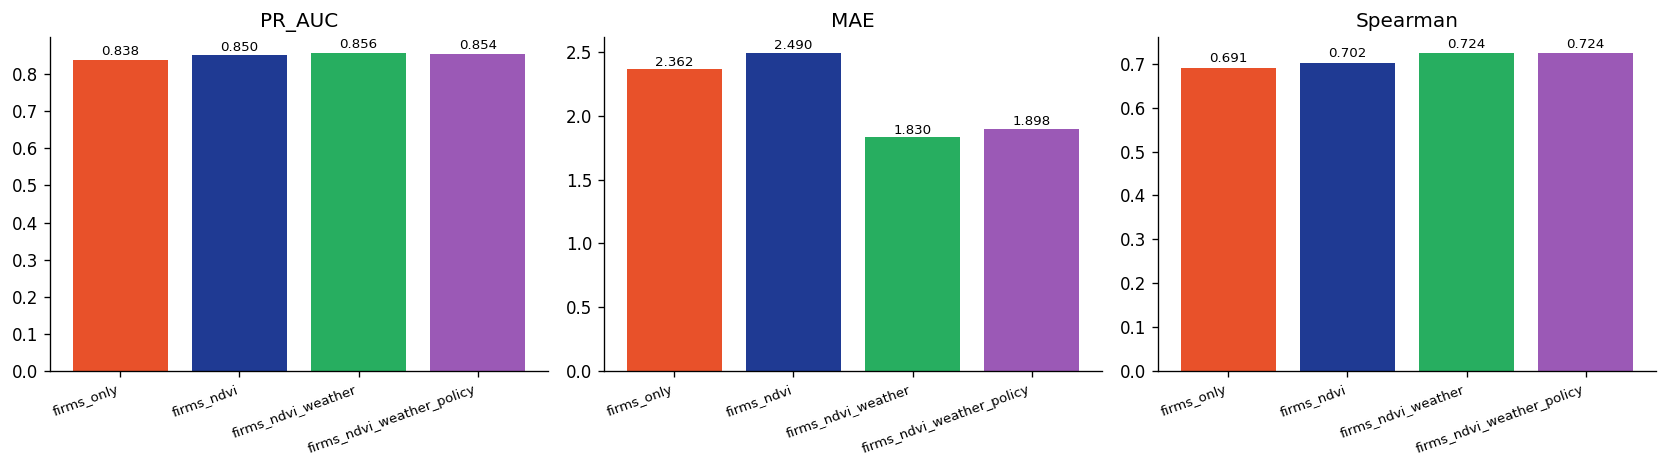

Saved figures/ablation_ladder.png


In [8]:
# Ablation plot (run after Phase 3)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics_to_plot = ['PR_AUC', 'MAE', 'Spearman']
colours = [ORANGE, NAVY, GREEN, PURPLE]
for ax, metric in zip(axes, metrics_to_plot):
    vals = ablation_df[metric].values
    bars = ax.bar(ablation_df['model'], vals, color=colours)
    ax.set_title(metric)
    ax.set_xticklabels(ablation_df['model'], rotation=20, ha='right', fontsize=8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('figures/ablation_ladder.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/ablation_ladder.png')


## Phase 4 — Optuna Hyperparameter Tuning
*(Do not execute here — run in Colab)*

100 Bayesian (TPE) trials on the winning ablation rung.
Final model retrained with best params on Train+Val, evaluated on Test.


In [10]:
# ── Phase 4: Optuna tuning ───────────────────────────────────
# DO NOT EXECUTE HERE — 100 trials × ~30 s = ~50 min on CPU
# Run in Colab
!pip install optuna -q
import optuna
from sklearn.metrics import average_precision_score as ap_score
optuna.logging.set_verbosity(optuna.logging.WARNING)

WINNER          = ablation_df.loc[ablation_df['PR_AUC'].idxmax(), 'model']
WINNER_FEATURES = [f for f in LADDER[WINNER] if f in train.columns]
print(f'Winning rung: {WINNER} ({len(WINNER_FEATURES)} features)')

def objective(trial):
    params = dict(
        objective              = 'reg:tweedie',
        tweedie_variance_power = trial.suggest_float('tweedie_variance_power', 1.1, 1.9),
        n_estimators           = 2000,
        learning_rate          = trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        max_depth              = trial.suggest_int('max_depth', 3, 10),
        min_child_weight       = trial.suggest_int('min_child_weight', 1, 20),
        subsample              = trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree       = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        reg_alpha              = trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        reg_lambda             = trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        random_state           = 42,
        n_jobs                 = -1,
        early_stopping_rounds  = 50,
    )
    m = xgb.XGBRegressor(**params)
    m.fit(train[WINNER_FEATURES], train[TARGET],
          eval_set=[(val[WINNER_FEATURES], val[TARGET])], verbose=False)
    val_pred = np.maximum(m.predict(val[WINNER_FEATURES]), 0)
    return ap_score((val[TARGET] > 0).astype(int), val_pred)

study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
)
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(f'\nBest val PR-AUC : {study.best_value:.4f}')
print(f'Best params     : {study.best_params}')

# Final model
best_params = dict(study.best_params)
best_params.update(dict(
    objective='reg:tweedie', n_estimators=3000,
    random_state=42, n_jobs=-1, early_stopping_rounds=50,
))
final_model = xgb.XGBRegressor(**best_params)
final_model.fit(
    train[WINNER_FEATURES], train[TARGET],
    eval_set=[(val[WINNER_FEATURES], val[TARGET])], verbose=False,
)
final_pred_test   = np.maximum(final_model.predict(test[WINNER_FEATURES]), 0)
final_metrics     = evaluate(test[TARGET].values, final_pred_test, 'xgb_tuned')

print('\n=== TUNED XGB — TEST 2023 ===')
for k, v in final_metrics.items():
    if k == 'model': continue
    print(f'  {k:<12}: {v:.4f}' if isinstance(v, float) else f'  {k:<12}: {v}')

final_model.save_model('models/xgb_tuned_final.json')
pd.DataFrame([final_metrics]).to_csv('outputs/final_metrics.csv', index=False)
study.trials_dataframe().to_csv('outputs/optuna_trials.csv', index=False)
print('\nSaved: models/xgb_tuned_final.json, outputs/final_metrics.csv')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 17.7 MB/s eta 0:00:00
Winning rung: firms_ndvi_weather (64 features)


  0%|          | 0/100 [00:00<?, ?it/s]


Best val PR-AUC : 0.9625
Best params     : {'tweedie_variance_power': 1.1511600288888517, 'learning_rate': 0.12167807836095834, 'max_depth': 8, 'min_child_weight': 8, 'subsample': 0.9418928735698248, 'colsample_bytree': 0.5909299759703034, 'reg_alpha': 0.4118943384661651, 'reg_lambda': 0.0026360268706371406}

=== TUNED XGB — TEST 2023 ===
  PR_AUC      : 0.8694
  ROC_AUC     : 0.8806
  Brier       : 0.1449
  MAE         : 1.8845
  RMSE        : 3.5957
  Spearman    : 0.7402
  Prec@50     : 0.9800
  Prec@100    : 0.9500

Saved: models/xgb_tuned_final.json, outputs/final_metrics.csv


## Phase 5 — SHAP Feature Importance
*(Do not execute here — run in Colab)*

Top-20 bar chart, family share pie, beeswarm plot.


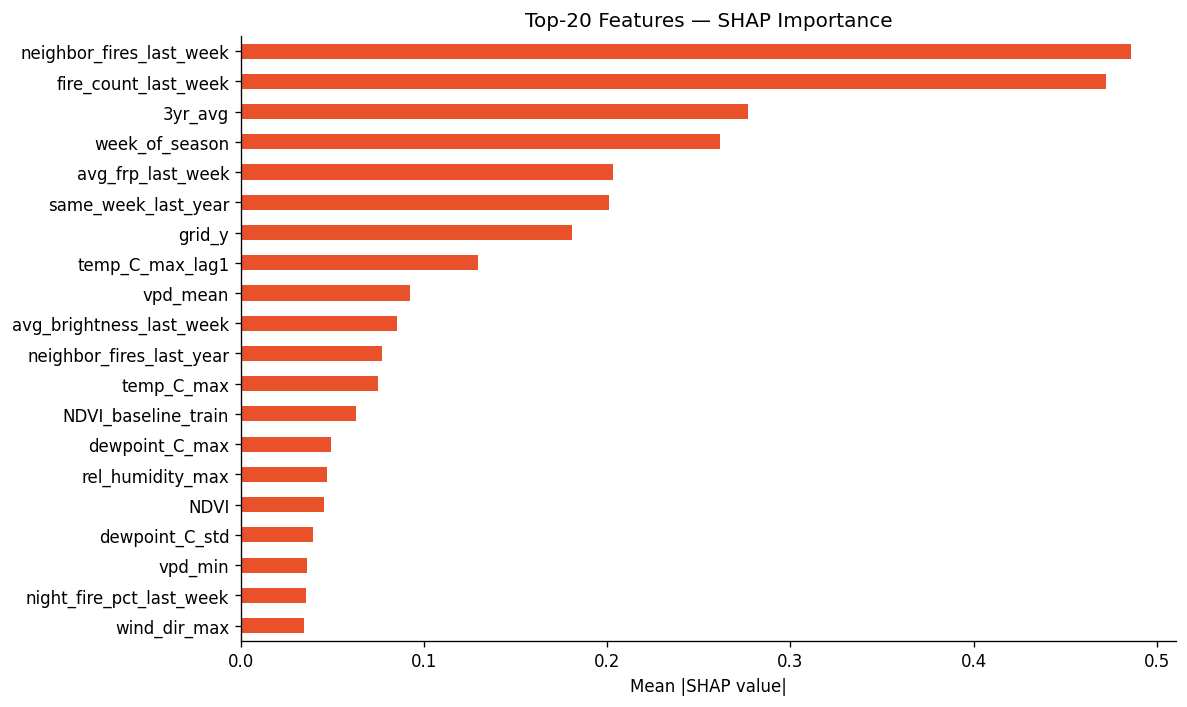

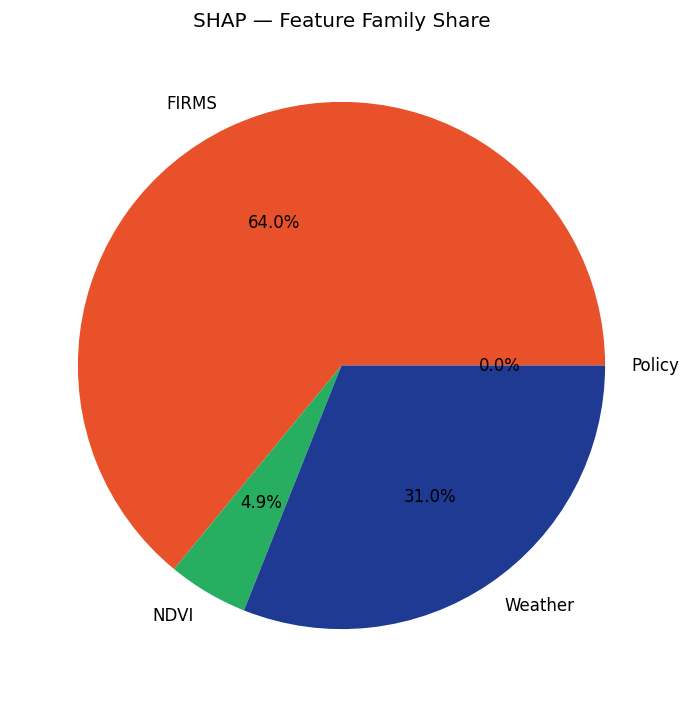

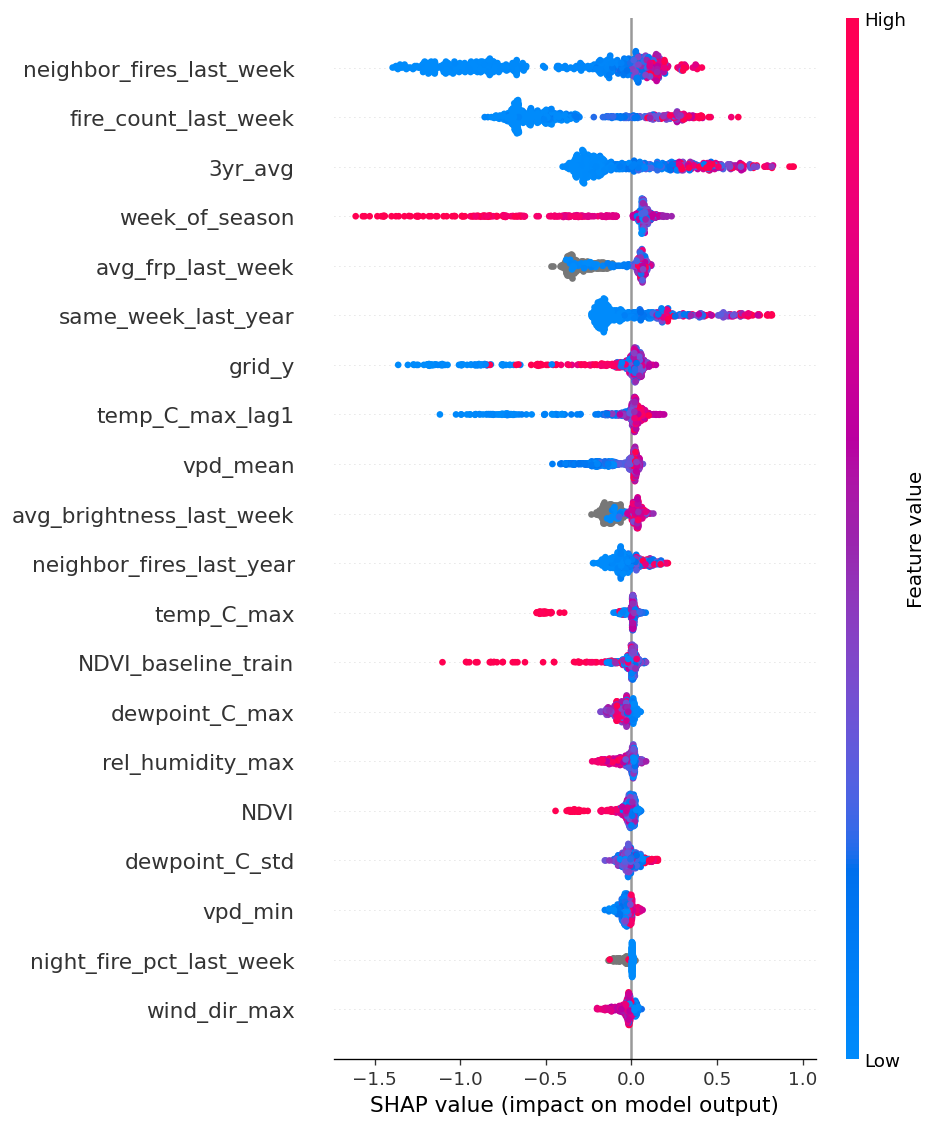

Saved SHAP figures and CSVs.


In [11]:
# ── Phase 5: SHAP ────────────────────────────────────────────
# DO NOT EXECUTE HERE
# Run in Colab

import shap

explainer   = shap.TreeExplainer(final_model)
shap_vals   = explainer.shap_values(test[WINNER_FEATURES])
shap_df     = pd.DataFrame(shap_vals, columns=WINNER_FEATURES)
importance  = shap_df.abs().mean().sort_values(ascending=False)
top20       = importance.head(20)

# Top-20 bar chart
fig, ax = plt.subplots(figsize=(10, 6))
top20[::-1].plot.barh(ax=ax, color=ORANGE)
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Top-20 Features — SHAP Importance')
plt.tight_layout()
plt.savefig('figures/shap_top20.png', dpi=150, bbox_inches='tight')
plt.show()

# Family share
families = {
    'FIRMS'   : BASE_FIRMS_COLS,
    'NDVI'    : NDVI_COLS,
    'Weather' : WEATHER_COLS,
    'Policy'  : POLICY_COLS,
}
family_share = {}
for fam, cols in families.items():
    cols_in = [c for c in cols if c in importance.index]
    family_share[fam] = importance[cols_in].sum() if cols_in else 0.0
family_share_s = pd.Series(family_share)
family_share_s = family_share_s / family_share_s.sum()

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(family_share_s.values, labels=family_share_s.index,
       autopct='%1.1f%%', colors=[ORANGE, GREEN, NAVY, PURPLE])
ax.set_title('SHAP — Feature Family Share')
plt.tight_layout()
plt.savefig('figures/shap_family_share.png', dpi=150, bbox_inches='tight')
plt.show()

# Beeswarm (via shap library)
shap.summary_plot(shap_vals, test[WINNER_FEATURES], max_display=20, show=False)
plt.savefig('figures/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

# Save importance tables
pd.DataFrame({'feature': importance.index, 'mean_shap': importance.values}).to_csv(
    'outputs/shap_importance.csv', index=False)
family_share_s.rename('share').reset_index().rename(columns={'index':'family'}).to_csv(
    'outputs/shap_family_share.csv', index=False)
print('Saved SHAP figures and CSVs.')


## Phase 6 — Calibration + Threshold Sensitivity
*(Do not execute here — run in Colab)*


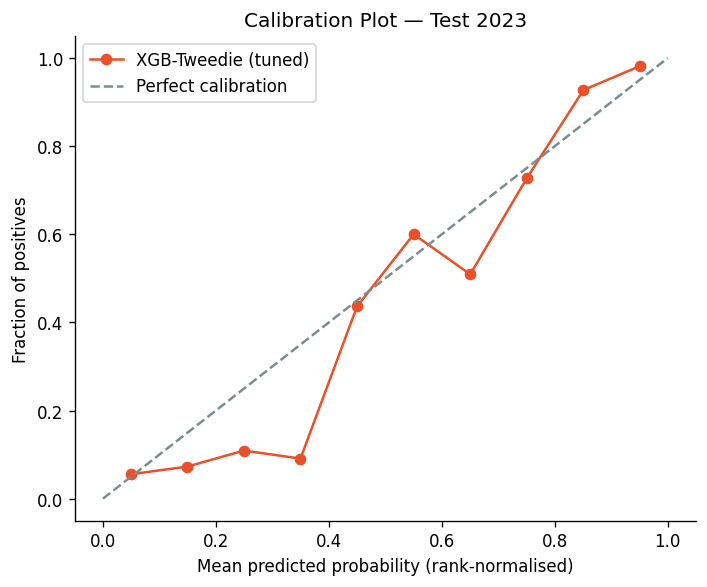

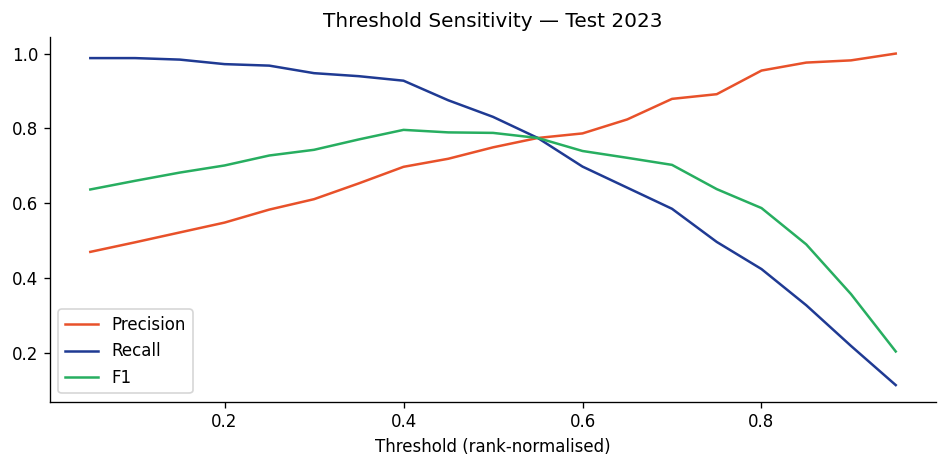

Phase 6 done.


In [12]:
# ── Phase 6: Calibration + threshold sweep ───────────────────
# DO NOT EXECUTE HERE

from sklearn.calibration import calibration_curve

# Rank-normalise predictions to [0,1]
prob_pred = pd.Series(final_pred_test).rank(pct=True).values
y_bin     = (test[TARGET].values > 0).astype(int)

# Calibration plot (10 bins)
fraction_pos, mean_pred = calibration_curve(y_bin, prob_pred, n_bins=10)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(mean_pred, fraction_pos, 'o-', color=ORANGE, label='XGB-Tweedie (tuned)')
ax.plot([0, 1], [0, 1], '--', color=GREY, label='Perfect calibration')
ax.set_xlabel('Mean predicted probability (rank-normalised)')
ax.set_ylabel('Fraction of positives')
ax.set_title('Calibration Plot — Test 2023')
ax.legend()
plt.tight_layout()
plt.savefig('figures/calibration_plot.png', dpi=150, bbox_inches='tight')
plt.show()

# Threshold sensitivity
thresholds   = np.arange(0.05, 0.96, 0.05)
precisions, recalls, f1s = [], [], []
for t in thresholds:
    pred_bin = (prob_pred >= t).astype(int)
    from sklearn.metrics import precision_score, recall_score
    p = precision_score(y_bin, pred_bin, zero_division=0)
    r = recall_score(y_bin, pred_bin, zero_division=0)
    f = 2*p*r/(p+r) if (p+r) > 0 else 0
    precisions.append(p); recalls.append(r); f1s.append(f)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, precisions, label='Precision', color=ORANGE)
ax.plot(thresholds, recalls,   label='Recall',    color=NAVY)
ax.plot(thresholds, f1s,       label='F1',        color=GREEN)
ax.set_xlabel('Threshold (rank-normalised)')
ax.set_title('Threshold Sensitivity — Test 2023')
ax.legend()
plt.tight_layout()
plt.savefig('figures/threshold_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Phase 6 done.')


## Phase 7 — Stratified MAE + Per-District + Lead-Time
*(Do not execute here — run in Colab)*

Three diagnostics:
1. MAE by fire-count bucket (0, 1–5, 6–20, 21+)
2. PR-AUC by latitude band (south/central/north Punjab)
3. Lead-time decay: retrain at t+1, t+2, t+4 week horizons


Stratified MAE:
       bucket       MAE   n
0 (zero-fire)  0.755706 301
          1-5  1.722337 145
         6-20  4.501362  91
          21+ 12.313926  12


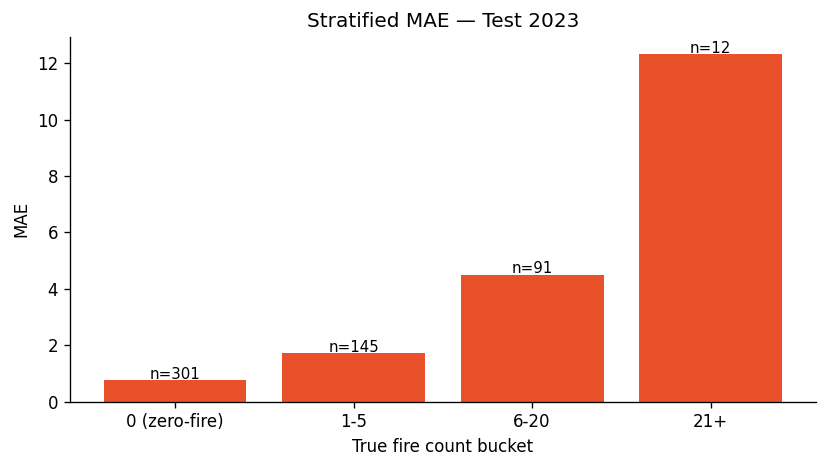


PR-AUC by latitude band:
lat_band   PR_AUC
   South 0.866033
 Central 0.911979
   North 0.750522

Lead-time analysis...
  t+1: PR-AUC=0.8034  MAE=3.051
  t+2: PR-AUC=0.8025  MAE=3.188
  t+4: PR-AUC=0.9291  MAE=3.913
Phase 7 done.


In [13]:
# ── Phase 7: Stratified diagnostics ─────────────────────────
# DO NOT EXECUTE HERE

# 7a. Stratified MAE by fire count bucket
bins     = [-1, 0, 5, 20, 9999]
labels   = ['0 (zero-fire)', '1-5', '6-20', '21+']
test_strat = test.copy()
test_strat['bucket']     = pd.cut(test_strat[TARGET], bins=bins, labels=labels)
test_strat['pred_final'] = final_pred_test

strat_mae = test_strat.groupby('bucket', observed=True).apply(
    lambda g: mean_absolute_error(g[TARGET], g['pred_final'])
).rename('MAE').reset_index()
strat_mae['n'] = test_strat.groupby('bucket', observed=True).size().values
print('Stratified MAE:')
print(strat_mae.to_string(index=False))
strat_mae.to_csv('outputs/strat_mae_master.csv', index=False)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(strat_mae['bucket'].astype(str), strat_mae['MAE'], color=ORANGE)
ax.set_xlabel('True fire count bucket')
ax.set_ylabel('MAE')
ax.set_title('Stratified MAE — Test 2023')
for i, row in strat_mae.iterrows():
    ax.text(i, row['MAE'] + 0.05, f'n={row["n"]}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('figures/strat_mae.png', dpi=150, bbox_inches='tight')
plt.show()

# 7b. PR-AUC by latitude band
LAT_MIN = 29.7; GRID_DEG = 0.07
test_strat['lat_center'] = LAT_MIN + test_strat['grid_y'] * GRID_DEG + GRID_DEG / 2
lat_bins   = [29.7, 30.5, 31.3, 32.6]
lat_labels = ['South', 'Central', 'North']
test_strat['lat_band'] = pd.cut(test_strat['lat_center'], bins=lat_bins, labels=lat_labels)
band_pr = test_strat.groupby('lat_band', observed=True).apply(
    lambda g: average_precision_score((g[TARGET] > 0).astype(int), g['pred_final'])
).rename('PR_AUC').reset_index()
print('\nPR-AUC by latitude band:')
print(band_pr.to_string(index=False))

# 7c. Lead-time decay: shift fire target forward by 1, 2, 4 weeks
print('\nLead-time analysis...')
ALL_FEATS = WINNER_FEATURES
lead_results = []
for lead in [1, 2, 4]:
    df_lead = df.copy()
    # Shift target: predict fires `lead` weeks ahead
    df_lead[f'target_t{lead}'] = df_lead.groupby('grid_id')[TARGET].shift(-lead)
    df_lead = df_lead.dropna(subset=[f'target_t{lead}'])
    tr_l = df_lead[df_lead['year'].isin(TRAIN_YEARS)]
    va_l = df_lead[df_lead['year'] == VAL_YEAR]
    te_l = df_lead[df_lead['year'] == TEST_YEAR]
    feats_l = [f for f in ALL_FEATS if f in tr_l.columns]
    m_l = xgb.XGBRegressor(**XGB_PARAMS)
    m_l.fit(tr_l[feats_l], tr_l[f'target_t{lead}'],
            eval_set=[(va_l[feats_l], va_l[f'target_t{lead}'])], verbose=False)
    pred_l = np.maximum(m_l.predict(te_l[feats_l]), 0)
    ev = evaluate(te_l[f'target_t{lead}'].values, pred_l, f't+{lead}')
    lead_results.append(ev)
    print(f'  t+{lead}: PR-AUC={ev["PR_AUC"]:.4f}  MAE={ev["MAE"]:.3f}')

lead_df = pd.DataFrame(lead_results)
lead_df.to_csv('outputs/lead_time_results.csv', index=False)
print('Phase 7 done.')


## Phase 8 — Predicted vs Observed Punjab Heatmap
*(Do not execute here — run in Colab)*

Side-by-side spatial heatmap: actual vs predicted fire counts summed over Test 2023.


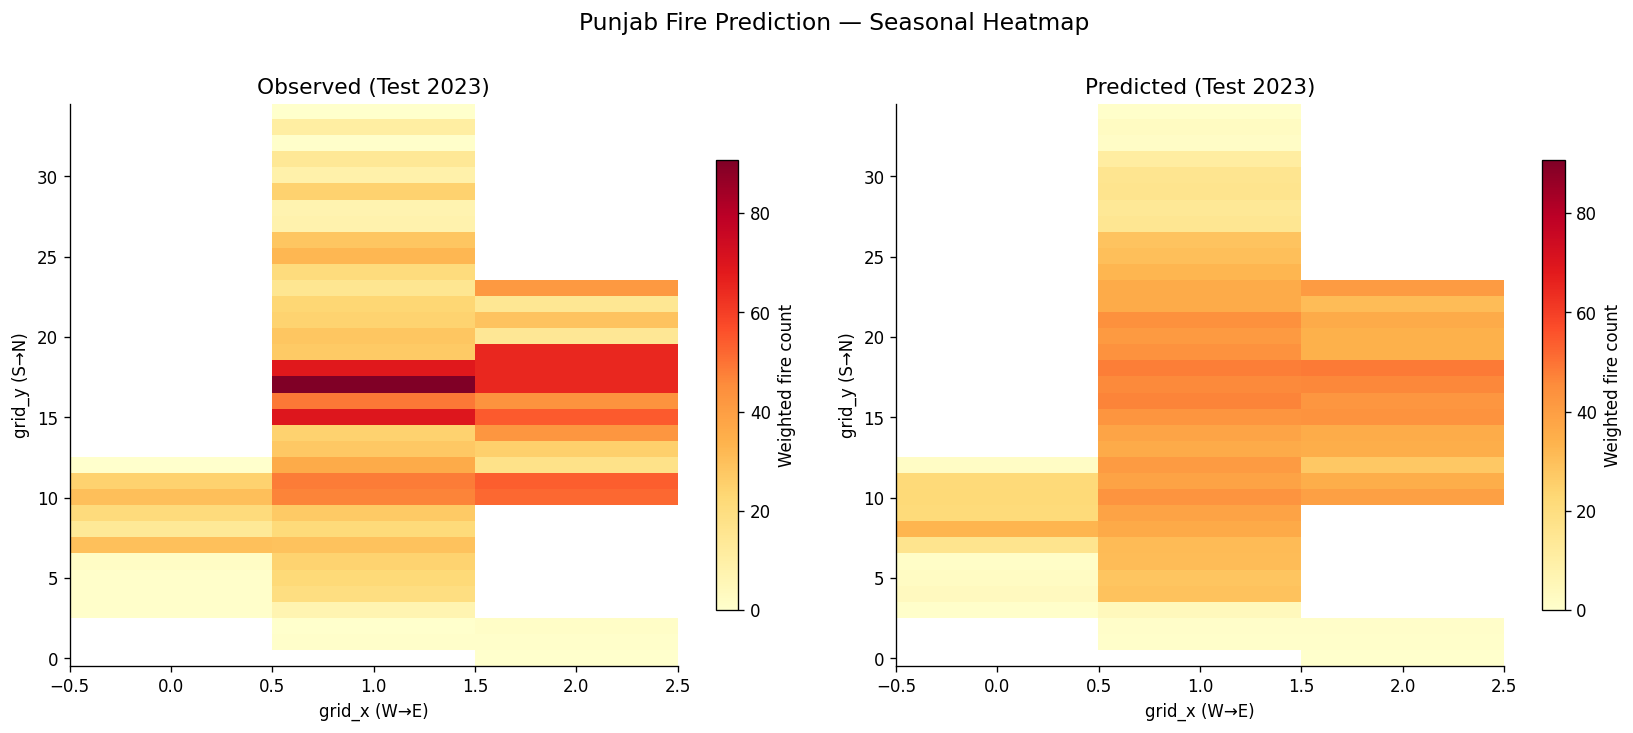

Saved figures/heatmap_pred_vs_actual.png


In [14]:
# ── Phase 8: Heatmap ─────────────────────────────────────────
# DO NOT EXECUTE HERE

test_map = test.copy()
test_map['pred'] = final_pred_test

# Sum over all weeks per grid cell
actual_grid = test_map.groupby(['grid_x', 'grid_y'])[TARGET].sum().reset_index()
pred_grid   = test_map.groupby(['grid_x', 'grid_y'])['pred'].sum().reset_index()

# Pivot to 2-D arrays
def to_grid(df, val_col, gx_col='grid_x', gy_col='grid_y'):
    pivot = df.pivot(index=gy_col, columns=gx_col, values=val_col)
    return pivot.values

actual_arr = to_grid(actual_grid, TARGET)
pred_arr   = to_grid(pred_grid,   'pred')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
vmax = max(np.nanmax(actual_arr), np.nanmax(pred_arr))
for ax, arr, title in zip(axes, [actual_arr, pred_arr],
                           ['Observed (Test 2023)', 'Predicted (Test 2023)']):
    im = ax.imshow(arr, origin='lower', cmap='YlOrRd', vmin=0, vmax=vmax, aspect='auto')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('grid_x (W→E)')
    ax.set_ylabel('grid_y (S→N)')
    plt.colorbar(im, ax=ax, shrink=0.8, label='Weighted fire count')

plt.suptitle('Punjab Fire Prediction — Seasonal Heatmap', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('figures/heatmap_pred_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/heatmap_pred_vs_actual.png')


## Phase 9 — ConvLSTM Stretch Model (PyTorch)
*(Do not execute here — run in Colab with GPU)*

Spatial-temporal deep model: 4-week sliding window → predict next week's fire count.
Subset of features: fire history + NDVI + weather (drop policy; too low frequency for temporal model).


In [15]:
# ── Phase 9: ConvLSTM ────────────────────────────────────────
# DO NOT EXECUTE HERE — GPU recommended
# Run in Colab

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

# ── ConvLSTM cell ─────────────────────────────────────────────
class ConvLSTMCell(nn.Module):
    def __init__(self, in_channels, hidden_channels, kernel_size=3):
        super().__init__()
        pad = kernel_size // 2
        self.hidden_channels = hidden_channels
        self.conv = nn.Conv2d(
            in_channels + hidden_channels,
            4 * hidden_channels,
            kernel_size=kernel_size, padding=pad,
        )

    def forward(self, x, h, c):
        combined = torch.cat([x, h], dim=1)
        gates    = self.conv(combined)
        i, f, o, g = gates.chunk(4, dim=1)
        i = torch.sigmoid(i)
        f = torch.sigmoid(f)
        o = torch.sigmoid(o)
        g = torch.tanh(g)
        c_next = f * c + i * g
        h_next = o * torch.tanh(c_next)
        return h_next, c_next

    def init_hidden(self, batch, H, W):
        return (
            torch.zeros(batch, self.hidden_channels, H, W, device=DEVICE),
            torch.zeros(batch, self.hidden_channels, H, W, device=DEVICE),
        )

# ── ConvLSTM model ────────────────────────────────────────────
class ConvLSTMModel(nn.Module):
    def __init__(self, in_channels, hidden_channels=32, n_layers=2):
        super().__init__()
        self.layers = nn.ModuleList()
        for i in range(n_layers):
            self.layers.append(
                ConvLSTMCell(in_channels if i == 0 else hidden_channels, hidden_channels)
            )
        self.head = nn.Conv2d(hidden_channels, 1, kernel_size=1)
        self.relu = nn.ReLU()

    def forward(self, x_seq):
        # x_seq: (batch, T, C, H, W)
        B, T, C, H, W = x_seq.shape
        h_list, c_list = [], []
        for layer in self.layers:
            h, c = layer.init_hidden(B, H, W)
            h_list.append(h); c_list.append(c)
        for t in range(T):
            x_t = x_seq[:, t]
            for i, layer in enumerate(self.layers):
                h_list[i], c_list[i] = layer(x_t, h_list[i], c_list[i])
                x_t = h_list[i]
        out = self.relu(self.head(h_list[-1]))  # (B, 1, H, W)
        return out.squeeze(1)                   # (B, H, W)

# ── Dataset ───────────────────────────────────────────────────
CONVLSTM_FEATS = [c for c in (BASE_FIRMS_COLS + NDVI_COLS + WEATHER_COLS)
                  if c in df.columns and c not in ("grid_x", "grid_y")]
WINDOW         = 4   # 4-week lookback
GX_SIZE        = df['grid_x'].max() + 1   # 36
GY_SIZE        = df['grid_y'].max() + 1   # 41

class FireGridDataset(Dataset):
    def __init__(self, data, feat_cols, target_col, window=4):
        self.window = window
        years = sorted(data['year'].unique())
        # Build (week-index, year) pairs for sliding windows
        self.samples = []
        for yr in years:
            yr_df = data[data['year'] == yr].sort_values('week')
            weeks  = sorted(yr_df['week'].unique())
            for i in range(window, len(weeks)):
                self.samples.append((yr_df, weeks, i))
        # Pre-fill grid arrays
        self.feat_cols  = feat_cols
        self.target_col = target_col
        self.gx  = GX_SIZE
        self.gy  = GY_SIZE
        self.n_feat = len(feat_cols)

    def __len__(self):
        return len(self.samples)

    def _week_grid(self, yr_df, week, cols):
        # Keep grid_x/grid_y separate to avoid duplicate columns if they appear in cols
        idx_cols = ['grid_x', 'grid_y']
        feat_cols_clean = [c for c in cols if c not in idx_cols]
        wdf = yr_df[yr_df['week'] == week][idx_cols + feat_cols_clean].fillna(0)
        arr = np.zeros((self.gy, self.gx, len(feat_cols_clean)), dtype=np.float32)
        for _, row in wdf.iterrows():
            gx = int(row['grid_x']); gy = int(row['grid_y'])
            arr[gy, gx] = row[feat_cols_clean].values.astype(np.float32)
        return arr  # (H, W, C)

    def __getitem__(self, idx):
        yr_df, weeks, i = self.samples[idx]
        # Input: WINDOW weeks of features → (T, C, H, W)
        x_list = []
        for t in range(self.window):
            wk  = weeks[i - self.window + t]
            arr = self._week_grid(yr_df, wk, self.feat_cols)  # (H, W, C) -- grid_x/y excluded inside
            x_list.append(torch.tensor(arr.transpose(2, 0, 1)))  # (C, H, W)
        x_seq = torch.stack(x_list, dim=0)  # (T, C, H, W)
        # Target: next week fire counts → (H, W)
        target_arr = self._week_grid(yr_df, weeks[i], [self.target_col])[:, :, 0]
        y = torch.tensor(target_arr)
        return x_seq, y

# Train / Val / Test datasets
train_ds = FireGridDataset(train, CONVLSTM_FEATS, TARGET, WINDOW)
val_ds   = FireGridDataset(val,   CONVLSTM_FEATS, TARGET, WINDOW)
test_ds  = FireGridDataset(test,  CONVLSTM_FEATS, TARGET, WINDOW)

train_dl = DataLoader(train_ds, batch_size=4, shuffle=True,  num_workers=0)
val_dl   = DataLoader(val_ds,   batch_size=4, shuffle=False, num_workers=0)
test_dl  = DataLoader(test_ds,  batch_size=4, shuffle=False, num_workers=0)

print(f'ConvLSTM dataset — Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}')
print(f'Input channels: {len(CONVLSTM_FEATS)}, Grid: {GY_SIZE}×{GX_SIZE}, Window: {WINDOW}')


Device: cuda
ConvLSTM dataset — Train: 20, Val: 5, Test: 5
Input channels: 62, Grid: 41×12, Window: 4


Epoch   1: train_loss=25.1565  val_loss=9.6900
Epoch   5: train_loss=20.9247  val_loss=8.5671
Epoch  10: train_loss=19.6626  val_loss=7.7699
Epoch  15: train_loss=18.4924  val_loss=6.8361
Epoch  20: train_loss=17.4606  val_loss=6.6352
Epoch  25: train_loss=16.6748  val_loss=6.3499
Epoch  30: train_loss=15.8979  val_loss=5.9506

Best val loss: 5.7400
Saved models/convlstm_best.pt

=== ConvLSTM — TEST 2023 ===
  PR_AUC      : 0.8238
  ROC_AUC     : 0.9231
  Brier       : 0.2107
  MAE         : 0.4340
  RMSE        : 2.0564
  Spearman    : 0.7970
  Prec@50     : 1.0000
  Prec@100    : 0.9600


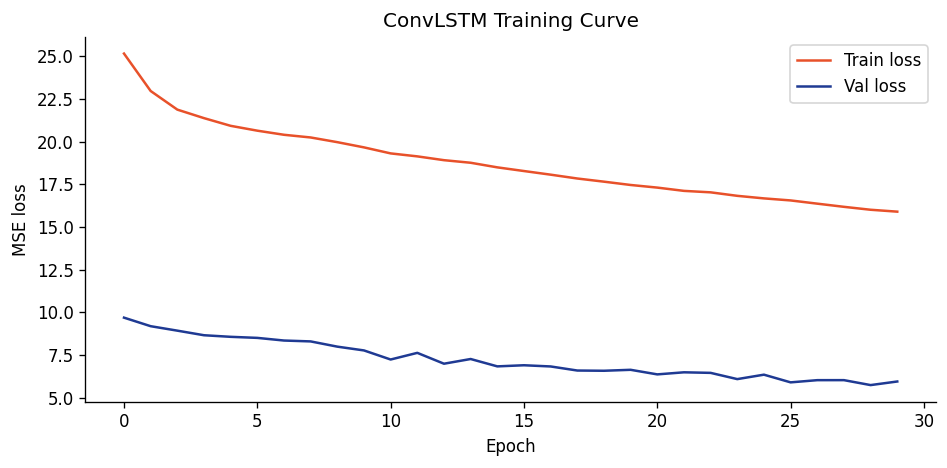

In [16]:
# ── ConvLSTM Training ─────────────────────────────────────────
# DO NOT EXECUTE HERE — GPU recommended

N_EPOCHS  = 30
LR        = 1e-3
HIDDEN_CH = 32
N_LAYERS  = 2

model_cl = ConvLSTMModel(
    in_channels=len(CONVLSTM_FEATS), hidden_channels=HIDDEN_CH, n_layers=N_LAYERS
).to(DEVICE)

optimizer  = torch.optim.Adam(model_cl.parameters(), lr=LR)
loss_fn    = nn.MSELoss()
scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

best_val_loss = float('inf')
train_losses, val_losses = [], []

for epoch in range(1, N_EPOCHS + 1):
    # ── Train ──
    model_cl.train()
    tr_loss = 0.0
    for x_seq, y in train_dl:
        x_seq, y = x_seq.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        pred = model_cl(x_seq)
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()
        tr_loss += loss.item()
    tr_loss /= len(train_dl)

    # ── Val ──
    model_cl.eval()
    va_loss = 0.0
    with torch.no_grad():
        for x_seq, y in val_dl:
            x_seq, y = x_seq.to(DEVICE), y.to(DEVICE)
            va_loss += loss_fn(model_cl(x_seq), y).item()
    va_loss /= len(val_dl)

    train_losses.append(tr_loss)
    val_losses.append(va_loss)
    scheduler.step(va_loss)

    if va_loss < best_val_loss:
        best_val_loss = va_loss
        torch.save(model_cl.state_dict(), 'models/convlstm_best.pt')

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}: train_loss={tr_loss:.4f}  val_loss={va_loss:.4f}')

print(f'\nBest val loss: {best_val_loss:.4f}')
print('Saved models/convlstm_best.pt')

# ── ConvLSTM evaluation on test ───────────────────────────────
model_cl.load_state_dict(torch.load('models/convlstm_best.pt', map_location=DEVICE))
model_cl.eval()
cl_preds, cl_true = [], []
with torch.no_grad():
    for x_seq, y in test_dl:
        x_seq = x_seq.to(DEVICE)
        pred  = model_cl(x_seq).cpu().numpy().flatten()
        cl_preds.extend(pred)
        cl_true.extend(y.numpy().flatten())

cl_preds = np.maximum(np.array(cl_preds), 0)
cl_true  = np.array(cl_true)
cl_metrics = evaluate(cl_true, cl_preds, 'convlstm')
print('\n=== ConvLSTM — TEST 2023 ===')
for k, v in cl_metrics.items():
    if k == 'model': continue
    print(f'  {k:<12}: {v:.4f}' if isinstance(v, float) else f'  {k:<12}: {v}')

# Training curve
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_losses, label='Train loss', color=ORANGE)
ax.plot(val_losses,   label='Val loss',   color=NAVY)
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE loss')
ax.set_title('ConvLSTM Training Curve')
ax.legend()
plt.tight_layout()
plt.savefig('figures/convlstm_training_curve.png', dpi=150, bbox_inches='tight')
plt.show()


## Phase 10 — Final Summary
*(Do not execute here — run in Colab after all phases complete)*


In [17]:
# ── Phase 10: Final summary ───────────────────────────────────
# DO NOT EXECUTE HERE — depends on all upstream phases

print('=' * 65)
print(' PUNJAB STUBBLE-BURNING FIRE PREDICTION — FINAL RESULTS')
print('=' * 65)

print('\n── Ablation Ladder ─────────────────────────────────────────')
print(ablation_df[['model','n_features','PR_AUC','MAE','Spearman']].round(4).to_string(index=False))

print('\n── Tuned XGB (Test 2023) ───────────────────────────────────')
fm = pd.read_csv('outputs/final_metrics.csv').iloc[0]
for k in ['PR_AUC','ROC_AUC','Brier','MAE','RMSE','Spearman','Prec@50','Prec@100']:
    if k in fm:
        print(f'  {k:<12}: {fm[k]:.4f}')

print('\n── SHAP Family Share ───────────────────────────────────────')
shap_fam = pd.read_csv('outputs/shap_family_share.csv')
print(shap_fam.to_string(index=False))

print('\n── Stratified MAE (Test 2023) ──────────────────────────────')
strat = pd.read_csv('outputs/strat_mae_master.csv')
print(strat.to_string(index=False))

print('\n── Lead-Time Decay ─────────────────────────────────────────')
lead = pd.read_csv('outputs/lead_time_results.csv')
print(lead[['model','PR_AUC','MAE','Spearman']].round(4).to_string(index=False))

print('\n── ConvLSTM vs XGB (Test 2023) ─────────────────────────────')
comp = pd.DataFrame([cl_metrics, final_metrics])
print(comp[['model','PR_AUC','MAE','Spearman']].round(4).to_string(index=False))

print('\n' + '=' * 65)
print(' End of pipeline. Figures saved in figures/, models in models/')
print('=' * 65)


 PUNJAB STUBBLE-BURNING FIRE PREDICTION — FINAL RESULTS

── Ablation Ladder ─────────────────────────────────────────
                    model  n_features  PR_AUC    MAE  Spearman
               firms_only          11  0.8376 2.3615    0.6907
               firms_ndvi          16  0.8497 2.4900    0.7024
       firms_ndvi_weather          64  0.8564 1.8301    0.7241
firms_ndvi_weather_policy          72  0.8537 1.8983    0.7243

── Tuned XGB (Test 2023) ───────────────────────────────────
  PR_AUC      : 0.8694
  ROC_AUC     : 0.8806
  Brier       : 0.1449
  MAE         : 1.8845
  RMSE        : 3.5957
  Spearman    : 0.7402
  Prec@50     : 0.9800
  Prec@100    : 0.9500

── SHAP Family Share ───────────────────────────────────────
 family    share
  FIRMS 0.640444
   NDVI 0.049241
Weather 0.310315
 Policy 0.000000

── Stratified MAE (Test 2023) ──────────────────────────────
       bucket       MAE   n
0 (zero-fire)  0.755706 301
          1-5  1.722337 145
         6-20  4.501362  91
